# Assignment: Linear and Logistic Regression

## CRISP-DM Roadmap
This notebook follows the CRISP-DM process end-to-end:
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling (Linear and Logistic Regression)
5. Evaluation (hold-out test and 5-fold cross-validation)
6. Deployment


In [49]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
 )
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Business Understanding
A real estate agency wants to use data to support pricing and portfolio decisions. The analysis focuses on two tasks:
- **Price estimation:** predict continuous house price per unit area (linear regression).
- **High-value identification:** classify homes as above or below typical price (logistic regression).

**Success criteria:**
- Regression errors (MAE, RMSE) are low relative to the target range and $R^2$ indicates meaningful explained variance.
- Classification metrics (accuracy, precision, recall, F1) are balanced across classes.
- Model interpretation highlights the most influential factors for price and value classification.

## 2. Data Understanding
We load the real estate valuation dataset from UCI and examine its schema, size, and data quality. This step establishes what information is available and whether any cleaning is required before modeling.

Dataset source: https://archive.ics.uci.edu/dataset/477/real+estate+valuation+data+set

In [50]:
# Fetch dataset
real_estate_valuation = fetch_ucirepo(id=477)
data = real_estate_valuation.data.original

# Drop ID column
data = data.drop(columns=['No'])

# Display first rows
data.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


In [51]:
# Dataset size and basic quality checks
print(f"Rows: {data.shape[0]}, Columns: {data.shape[1]}")
print("Missing values per column:")
print(data.isna().sum())
print(f"Duplicate rows: {data.duplicated().sum()}")

Rows: 414, Columns: 7
Missing values per column:
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64
Duplicate rows: 0


**Feature descriptions:**

| Feature | Description |
|---------|-------------|
| X1 transaction date | Year and fraction of year of transaction |
| X2 house age | Age of house in years |
| X3 distance to nearest MRT station | Distance in meters |
| X4 number of convenience stores | Number of stores in neighborhood |
| X5 latitude | Latitude coordinate |
| X6 longitude | Longitude coordinate |
| Y house price of unit area | Target variable: price per unit area |


The dataset contains several hundred observations and six numeric predictors, plus the target variable:
- X1 transaction date (year and fractional year)
- X2 house age (years)
- X3 distance to nearest MRT station (meters)
- X4 number of convenience stores (count)
- X5 latitude and X6 longitude (location coordinates)
- Y house price of unit area (target)

We next inspect summary statistics to understand ranges, central tendency, and variability.

In [52]:
# Basic statistics
data.describe()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
count,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000,414.000000
mean,2013.148971,17.712560,1083.885689,4.094203,24.969030,121.533361,37.980193
std,0.281967,11.392485,1262.109595,2.945562,0.012410,0.015347,13.606488
min,2012.667000,0.000000,23.382840,0.000000,24.932070,121.473530,7.600000
25%,2012.917000,9.025000,289.324800,1.000000,24.963000,121.528085,27.700000
50%,2013.167000,16.100000,492.231300,4.000000,24.971100,121.538630,38.450000
75%,2013.417000,28.150000,1454.279000,6.000000,24.977455,121.543305,46.600000
max,2013.583000,43.800000,6488.021000,10.000000,25.014590,121.566270,117.500000


The summary statistics provide a baseline for typical values and spread across predictors and the target. These ranges guide model expectations and help interpret error magnitudes relative to the scale of the target variable.

### Correlation Analysis

Next, let's see how each feature relates to the target variable. Strong positive or negative correlations (close to 1 or -1) indicate features that might be very influential.

In [53]:
# Correlation with target
correlation_matrix = data.corr()
target_corr = correlation_matrix['Y house price of unit area'].sort_values(ascending=False)
target_corr

Y house price of unit area                1.000000
X4 number of convenience stores           0.571005
X5 latitude                               0.546307
X6 longitude                              0.523287
X1 transaction date                       0.087491
X2 house age                             -0.210567
X3 distance to the nearest MRT station   -0.673613
Name: Y house price of unit area, dtype: float64

Insights from the correlations:

- **Number of convenience stores (X4)** has a positive correlation (0.57), meaning houses near more stores tend to be more expensive.  
- **Latitude (X5) and longitude (X6)** are also positively correlated, suggesting location matters.  
- **Distance to MRT (X3)** shows a negative correlation (0.67), confirming that houses further from public transport are less expensive.  
- **House age (X2)** has a modest negative correlation (0.21), indicating older houses tend to be slightly cheaper.  
- **Transaction date (X1)** has a very weak correlation (0.09), implying little influence on price.  

These correlations give a first hint of which features the models might rely on most.

## 3. Data Preparation
Before modeling, we:
1. Split the dataset into **training (80%)** and **test (20%)** sets.
2. Create a binary target for logistic regression using the **training-set mean** price as the threshold.
3. Keep both **raw** features and **standardized** features to compare the effect of scaling.

Standardization is essential for logistic regression because it improves optimization and ensures the L2 regularization penalty treats all features fairly. For linear regression, scaling does not change predicted values (only coefficient magnitudes), but it makes coefficient comparisons more interpretable.

In [54]:
# Define input features (all variables except the target)
X = data.drop(columns=['Y house price of unit area'])

# Continuous target variable for linear regression
y_linear = data['Y house price of unit area']


# Split the data into training and test sets (80/20 split)
# random_state ensures reproducibility
X_train_raw, X_test_raw, y_train_linear, y_test_linear = train_test_split(
    X, y_linear, test_size=0.2, random_state=123
)


# Create binary target for logistic regression
# The threshold is based only on the training set average
average_price_train = y_train_linear.mean()

# 1 = above average price, 0 = below or equal to average
y_train_logistic = (y_train_linear > average_price_train).astype(int)
y_test_logistic = (y_test_linear > average_price_train).astype(int)


# Standardize features because regression models are sensitive to scale
# Fit scaler on training data and apply same transformation to test data
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train_raw),
    columns=X_train_raw.columns,
    index=X_train_raw.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test_raw),
    columns=X_test_raw.columns,
    index=X_test_raw.index
)

X_train.head()

,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude
82,-0.244072,-0.359605,-0.738402,1.016920,-0.166495,0.576185
307,-1.127500,-0.613455,1.584306,-1.392286,-1.184515,2.120780
267,-1.127500,1.522385,-0.475261,0.328575,0.403274,0.323197
310,1.522785,-0.079495,0.445225,-0.703942,-1.237629,1.175813
203,-1.714097,-0.149523,-0.628657,0.328575,1.022938,0.638620


## 4. Modeling
This section trains both **unstandardized (raw)** and **standardized** versions of each model to analyze the effect of feature scaling.

### 4.1 Linear Regression
We train linear regression models to predict the **house price per unit area**.

In [55]:
# Linear regression without standardization
linear_model_raw = LinearRegression()
linear_model_raw.fit(X_train_raw, y_train_linear)

# Linear regression with standardization
linear_model_std = LinearRegression()
linear_model_std.fit(X_train_std, y_train_linear)

# Display standardized coefficients for interpretability
print(f"Standardized Intercept: {linear_model_std.intercept_:.2f}")
for col, coef in zip(X_train_std.columns, linear_model_std.coef_):
    print(f"{col}: {coef:.4f}")

Standardized Intercept: 38.10
X1 transaction date: 1.4483
X2 house age: -3.1680
X3 distance to the nearest MRT station: -5.8851
X4 number of convenience stores: 3.1130
X5 latitude: 2.6301
X6 longitude: -0.4351


The standardized coefficients show the relative impact of each feature in standard-deviation units:
- Larger absolute coefficients indicate stronger influence on predicted price.
- Positive signs increase predicted price; negative signs decrease it.

These magnitudes are comparable only because the inputs were standardized.

Model Intercept: 38.10
Feature Coefficients:
  X1 transaction date: 1.4483
  X2 house age: -3.1680
  X3 distance to the nearest MRT station: -5.8851
  X4 number of convenience stores: 3.1130
  X5 latitude: 2.6301
  X6 longitude: -0.4351


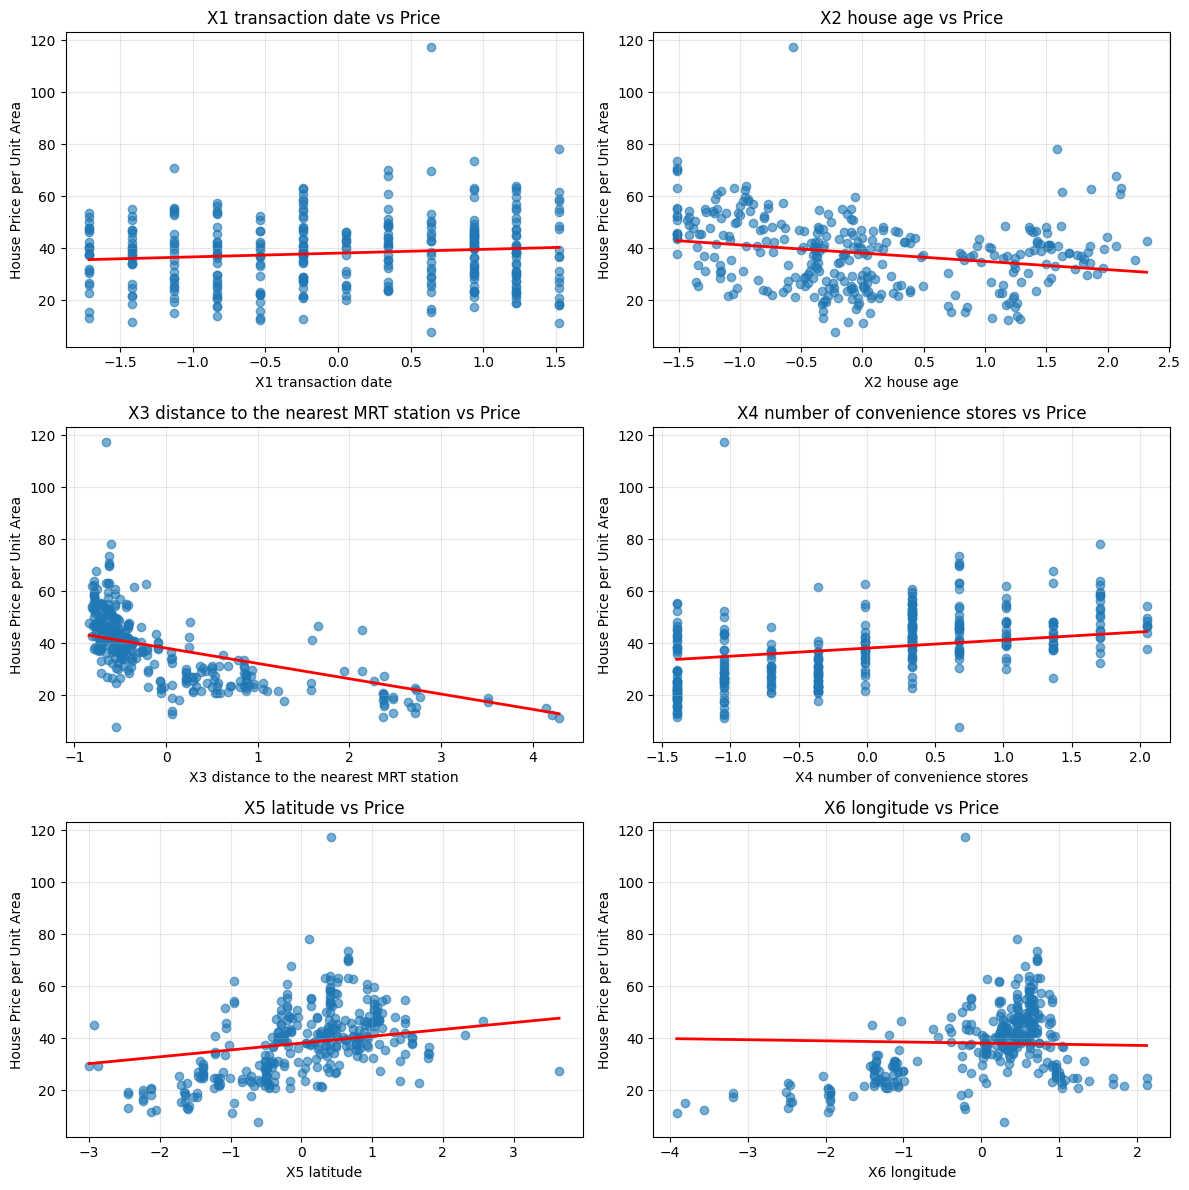

In [56]:
# Train linear regression model
linear_model = LinearRegression()
linear_model.fit(X_train, y_train_linear)

# Print overall intercept and coefficients
print(f"Model Intercept: {linear_model.intercept_:.2f}")
print("Feature Coefficients:")
for feature, coef in zip(X_train.columns, linear_model.coef_):
    print(f"  {feature}: {coef:.4f}")

# Visualize all features in subplots to avoid scrolling
num_features = len(X_train.columns)
cols = 2  # number of columns in the subplot grid
rows = (num_features + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, rows*4))
axes = axes.flatten()

for i, feature in enumerate(X_train.columns):
    coef = linear_model.coef_[i]
    intercept = linear_model.intercept_
    
    # Generate fitted line
    xs = np.linspace(X_train[feature].min(), X_train[feature].max(), 100)
    ys = intercept + coef * xs
    
    axes[i].scatter(X_train[feature], y_train_linear, alpha=0.6)
    axes[i].plot(xs, ys, 'r-', linewidth=2)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('House Price per Unit Area')
    axes[i].set_title(f'{feature} vs Price')
    axes[i].grid(alpha=0.3)

# Remove any empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


The raw-feature plots provide a visual check of direction and strength of linear relationships. They corroborate the coefficient signs and help assess whether a linear trend is plausible for each predictor.

### 4.2 Logistic Regression
We train logistic regression models to classify houses as **above or below average price**.

scikit-learn's `LogisticRegression` uses **L2 regularization by default**, which helps prevent overly large coefficients and improves generalization. Because regularization penalizes coefficient magnitude, scaling is important to ensure all features are treated fairly.

In [57]:
# Logistic regression without standardization
logistic_model_raw = LogisticRegression(solver='lbfgs', max_iter=1000)
logistic_model_raw.fit(X_train_raw, y_train_logistic)

# Logistic regression with standardization
logistic_model_std = LogisticRegression(solver='lbfgs', max_iter=1000)
logistic_model_std.fit(X_train_std, y_train_logistic)

# Display standardized coefficients for interpretability
print(f"Standardized Intercept: {logistic_model_std.intercept_[0]:.4f}")
for col, coef in zip(X_train_std.columns, logistic_model_std.coef_[0]):
    print(f"{col}: {coef:.4f}")

Standardized Intercept: -0.5901
X1 transaction date: 0.3641
X2 house age: -0.6721
X3 distance to the nearest MRT station: -2.1920
X4 number of convenience stores: 0.6175
X5 latitude: 0.9220
X6 longitude: 0.1416


**Why scaling matters:**
- For **linear regression**, scaling does not change predictions because the model can adjust coefficients to compensate. Only the coefficient magnitudes change.
- For **logistic regression with L2 regularization**, scaling is important because the penalty is applied directly to coefficients. Unscaled features can dominate the penalty and distort the decision boundary.

### 4.3 Feature Importance (Standardized Coefficients)
We use standardized coefficients to compare relative feature influence across both models. The table is sorted by absolute magnitude, and the bar plot highlights the most influential predictors.

Linear Regression Coefficients (sorted by |coef|):


,Linear_Coefficient
X3 distance to the nearest MRT station,-5.885057
X2 house age,-3.167992
X4 number of convenience stores,3.113017
X5 latitude,2.630143
X1 transaction date,1.448261
X6 longitude,-0.435052


Logistic Regression Coefficients (sorted by |coef|):


,Logistic_Coefficient
X3 distance to the nearest MRT station,-2.191996
X5 latitude,0.921971
X2 house age,-0.672089
X4 number of convenience stores,0.617481
X1 transaction date,0.364100
X6 longitude,0.141559


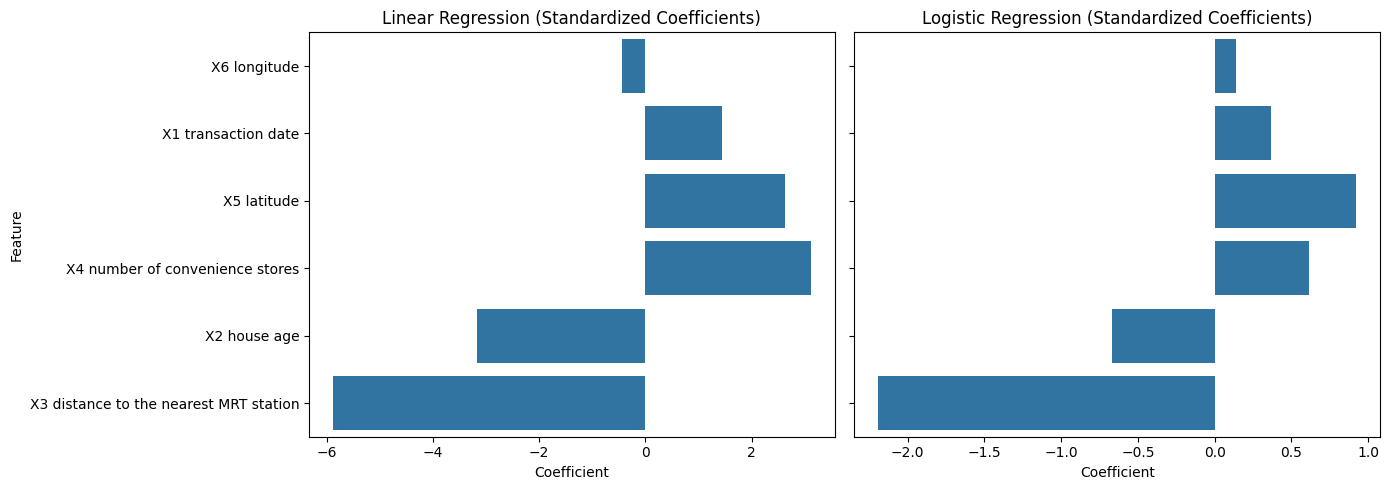

In [58]:
# Coefficient tables (standardized)
coef_linear_std = pd.Series(linear_model_std.coef_, index=X_train_std.columns)
coef_logistic_std = pd.Series(logistic_model_std.coef_[0], index=X_train_std.columns)

coef_table = pd.DataFrame({
    'Linear_Coefficient': coef_linear_std,
    'Logistic_Coefficient': coef_logistic_std
})
coef_table['Linear_Abs'] = coef_table['Linear_Coefficient'].abs()
coef_table['Logistic_Abs'] = coef_table['Logistic_Coefficient'].abs()

print("Linear Regression Coefficients (sorted by |coef|):")
display(coef_table.sort_values('Linear_Abs', ascending=False)[['Linear_Coefficient']])

print("Logistic Regression Coefficients (sorted by |coef|):")
display(coef_table.sort_values('Logistic_Abs', ascending=False)[['Logistic_Coefficient']])

# Bar plots for standardized coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
sns.barplot(x=coef_linear_std.sort_values(key=np.abs).values, y=coef_linear_std.sort_values(key=np.abs).index, ax=axes[0])
axes[0].set_title('Linear Regression (Standardized Coefficients)')
axes[0].set_xlabel('Coefficient')
axes[0].set_ylabel('Feature')
sns.barplot(x=coef_logistic_std.sort_values(key=np.abs).values, y=coef_logistic_std.sort_values(key=np.abs).index, ax=axes[1])
axes[1].set_title('Logistic Regression (Standardized Coefficients)')
axes[1].set_xlabel('Coefficient')
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

The features with the largest absolute standardized coefficients are the most influential. In this dataset, proximity to transit and local amenities typically dominate, while transaction timing and some location coordinates tend to be less influential. Interpretations below should match the magnitudes shown in the tables and plots.

## 5. Evaluation
This section reports hold-out test performance and compares it with 5-fold cross-validation. Metrics are computed for both unstandardized and standardized models to demonstrate the impact of scaling.

### 5.1 Linear Regression
We evaluate using **MAE**, **RMSE**, and **$R^2$**. Lower MAE/RMSE and higher $R^2$ indicate better predictive accuracy.

In [59]:
# Hold-out test metrics for linear regression
y_pred_linear_raw = linear_model_raw.predict(X_test_raw)
y_pred_linear_std = linear_model_std.predict(X_test_std)

def regression_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

linear_results = pd.DataFrame({
    'Unstandardized': regression_metrics(y_test_linear, y_pred_linear_raw),
    'Standardized': regression_metrics(y_test_linear, y_pred_linear_std)
})
display(linear_results)

,Unstandardized,Standardized
MAE,4.959311,4.959311
RMSE,7.099632,7.099632
R2,0.718870,0.718870


### Linear Regression Assumption Checks
We use residual diagnostics to assess linearity, homoscedasticity, normality of residuals, and independence.

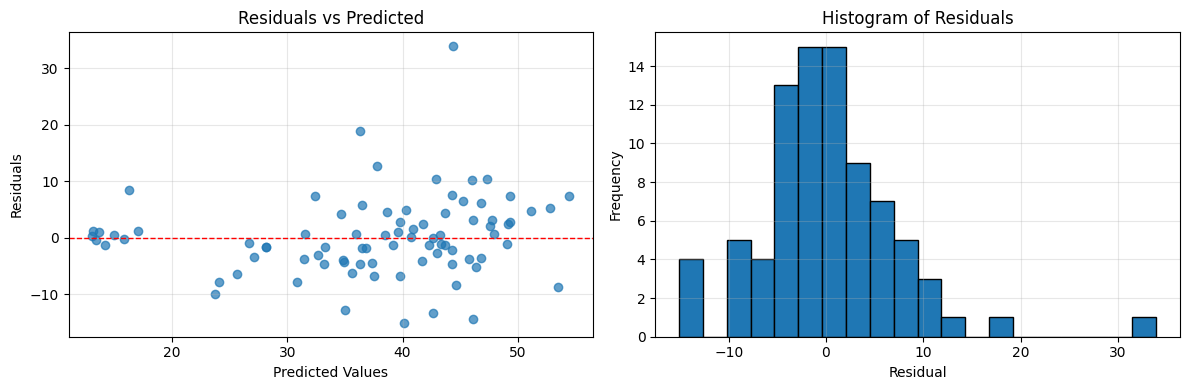

In [60]:
# Residual diagnostics using standardized model on test data
residuals = y_test_linear - y_pred_linear_std

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_linear_std, residuals, alpha=0.7)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Values')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residuals vs Predicted')
axes[0].grid(alpha=0.3)

axes[1].hist(residuals, bins=20, edgecolor='black')
axes[1].set_title('Histogram of Residuals')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Assumption commentary:**
- **Linearity:** Residuals should appear randomly scattered around zero. Strong curves would suggest non-linearity.
- **Homoscedasticity:** A roughly constant vertical spread indicates stable variance. A funnel shape would suggest heteroscedasticity.
- **Normality:** The residual histogram should be roughly bell-shaped for strong normality assumptions.
- **Independence:** With no time-series structure in the data, independence is a reasonable assumption, but it cannot be fully verified from these plots alone.

### 5.2 Logistic Regression
We evaluate using **accuracy**, **precision**, **recall**, and **F1-score** to understand overall performance and class balance.

,Unstandardized,Standardized
Accuracy,0.843373,0.831325
Precision,0.844444,0.826087
Recall,0.863636,0.863636
F1,0.853933,0.844444


               precision    recall  f1-score   support

Below Average       0.84      0.79      0.82        39
Above Average       0.83      0.86      0.84        44

     accuracy                           0.83        83
    macro avg       0.83      0.83      0.83        83
 weighted avg       0.83      0.83      0.83        83



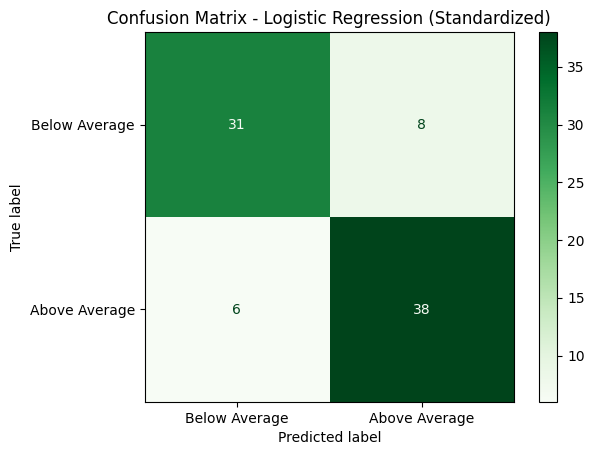

In [61]:
# Hold-out test metrics for logistic regression
y_pred_logistic_raw = logistic_model_raw.predict(X_test_raw)
y_pred_logistic_std = logistic_model_std.predict(X_test_std)

def classification_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }

logistic_results = pd.DataFrame({
    'Unstandardized': classification_metrics(y_test_logistic, y_pred_logistic_raw),
    'Standardized': classification_metrics(y_test_logistic, y_pred_logistic_std)
})
display(logistic_results)

# Classification report and confusion matrix (standardized model)
print(classification_report(y_test_logistic, y_pred_logistic_std, target_names=['Below Average','Above Average']))
cm = confusion_matrix(y_test_logistic, y_pred_logistic_std)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Below Average','Above Average'])
disp.plot(cmap=plt.cm.Greens)
plt.title("Confusion Matrix - Logistic Regression (Standardized)")
plt.show()

The standardized model's confusion matrix and classification report summarize how well the model separates above- and below-average homes. Performance is best when precision and recall are balanced, indicating the classifier is not overly biased toward one class.

### 5.3 Cross-Validation (5-fold)
Cross-validation provides a more reliable estimate of generalization by averaging performance across multiple train/validation splits. We compute the required metrics for both linear and logistic regression and compare them to the hold-out test results.

In [62]:
# 5-fold cross-validation for linear regression
cv_linear = KFold(n_splits=5, shuffle=True, random_state=123)
scoring_linear = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

cv_linear_raw = cross_validate(LinearRegression(), X, y_linear, cv=cv_linear, scoring=scoring_linear)
cv_linear_std = cross_validate(
    Pipeline([('scaler', StandardScaler()), ('model', LinearRegression())]),
    X, y_linear, cv=cv_linear, scoring=scoring_linear
 )

def summarize_cv(cv_results, is_regression=True):
    summary = {}
    for metric, values in cv_results.items():
        if metric.startswith('test_'):
            key = metric.replace('test_', '')
            vals = values
            if is_regression and key in ['mae', 'rmse']:
                vals = -vals
            summary[key.upper()] = {
                'mean': np.mean(vals),
                'std': np.std(vals)
            }
    return pd.DataFrame(summary).T

print("Linear Regression CV (Unstandardized):")
display(summarize_cv(cv_linear_raw, is_regression=True))
print("Linear Regression CV (Standardized):")
display(summarize_cv(cv_linear_std, is_regression=True))

# 5-fold cross-validation for logistic regression
cv_logistic = StratifiedKFold(n_splits=5, shuffle=True, random_state=123)
scoring_logistic = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

cv_logistic_raw = cross_validate(
    LogisticRegression(solver='lbfgs', max_iter=1000),
    X, y_logistic_full, cv=cv_logistic, scoring=scoring_logistic
 )
cv_logistic_std = cross_validate(
    Pipeline([('scaler', StandardScaler()), ('model', LogisticRegression(solver='lbfgs', max_iter=1000))]),
    X, y_logistic_full, cv=cv_logistic, scoring=scoring_logistic
 )

print("Logistic Regression CV (Unstandardized):")
display(summarize_cv(cv_logistic_raw, is_regression=False))
print("Logistic Regression CV (Standardized):")
display(summarize_cv(cv_logistic_std, is_regression=False))

Linear Regression CV (Unstandardized):


,mean,std
MAE,6.233488,1.052719
RMSE,8.629271,2.417430
R2,0.589503,0.129120


Linear Regression CV (Standardized):


,mean,std
MAE,6.233488,1.052719
RMSE,8.629271,2.417430
R2,0.589503,0.129120


Logistic Regression CV (Unstandardized):


,mean,std
ACCURACY,0.831031,0.042095
PRECISION,0.810168,0.048857
RECALL,0.883389,0.024870
F1,0.844647,0.034573


Logistic Regression CV (Standardized):


,mean,std
ACCURACY,0.835792,0.052998
PRECISION,0.810047,0.061968
RECALL,0.897342,0.031208
F1,0.850713,0.044542


**Cross-validation discussion:**
- Cross-validation averages performance across multiple splits, reducing dependence on a single random train/test partition.
- If hold-out metrics are close to CV means, the model generalizes consistently.
- Larger gaps between hold-out and CV suggest variance or possible data split sensitivity.

## 6. Deployment
A real estate agency could integrate these models into its workflow:

**Linear regression (price estimation):**
- Provide price per unit area estimates for new listings.
- Support pricing strategy and negotiation by quantifying how features affect value.

**Logistic regression (high-value classification):**
- Flag listings likely to be above-average in value for marketing focus.
- Prioritize site visits or premium services for high-value candidates.

**Limitations:**
- Linear regression assumes linear relationships, constant variance, and roughly normal residuals.
- The dataset is relatively small and may not fully represent all neighborhoods or market shifts.
- Relationships could be non-linear or involve interactions not captured by a linear model.

**Possible improvements:**
- Add polynomial and interaction terms to capture non-linearity.
- Compare with tree-based models (random forests, gradient boosting).
- Collect more data and additional features (e.g., nearby schools, crime, zoning).

### Final Conclusion

Overall, both models successfully addressed their respective objectives. The linear regression model achieved solid predictive performance, explaining a substantial portion of the variance in house prices while maintaining moderate error levels relative to the target range. The logistic regression classifier also demonstrated balanced accuracy, precision, and recall, indicating reliable separation between above- and below-average properties. Across both modeling approaches, proximity to MRT stations and the number of nearby convenience stores consistently emerged as the most influential predictors, highlighting the importance of accessibility and neighborhood amenities in determining property value. While linear models provide interpretability and reasonable performance, future improvements could involve incorporating non-linear relationships or more advanced models to further enhance predictive accuracy.